# **Milestone** | NYC Public High School Data Analysis

<div style="text-align: center;">
<img src="https://upload.wikimedia.org/wikipedia/commons/b/b1/NYC_DOE_Logo.png" alt="NYC DOE Logo" width="300"/>
</div>


# Introduction
For this Milestone, you’re joining the New York City Department of Education as a data analyst intern. Your first assignment is to explore a dataset containing recent information on NYC public high schools, including enrollment numbers, demographics, and socioeconomic indicators.

Your goal is to better understand the landscape of public high school education in NYC by analyzing key metrics such as total enrollment, percentage of students with disabilities, English learners, and students living in poverty. By visualizing these variables and investigating potential relationships between them, you’ll help uncover patterns and raise important questions that could inform future policy decisions.

Your work here lays the foundation for data-driven improvements in educational equity, resource allocation, and student support across the city’s schools.


To start, import both the pandas library and the plotly.express library.

In [88]:
# Import libraries here
import pandas as pd
import plotly.express as px

# Task 1: Explore the dataset

You will use the `schools.csv` dataset to complete your analysis. Each row gives data for a particular school in New York City.


The `schools` dataset contains the following information:
- **school_name**: Name of the school
- **total_enrollment**: Number of students enrolled
- **percent_students_with_disabilities**: Percentage of students with disabilities
- **percent_english_learners**: Percentage of students who speak English as a second language (ESL)
- **percent_poverty**: Percentage of students who are below the poverty line


Load the dataset into a DataFrame and randomly preview 10 rows.

In [89]:
# Load the data
df = pd.read_csv("datasets/schools.csv")
# Preview 10 randomly chosen rows
df.sample(10)

,school_name,total_enrollment,percent_students_with_disabilities,percent_english_learners,percent_poverty
852,P.S. 025 Eubie Blake School,156.6,27.78,8.14,96.94
1002,P.S. 092 Harry T. Stewart Sr.,902.4,18.88,32.42,72.64
571,J.H.S. 223 The Montauk,968.8,13.80,34.30,95.64
1376,P.S. 396,360.8,27.68,21.46,91.26
904,P.S. 045 Clarence Witherspoon,379.6,19.38,7.74,88.36
1295,P.S. 245,304.8,20.96,12.14,94.22
896,P.S. 042 Benjamin Altman,722.4,16.00,30.74,66.32
1403,P.S. 889,82.0,7.30,11.00,75.60
1120,P.S. 147 Isaac Remsen,315.0,18.92,9.64,83.38
1735,The School for Inquiry and Social Justice,450.2,27.10,10.10,74.42


In [90]:
# List the columns of the DataFrame
print(f"The columns of the schools dataset are: {df.columns.tolist()}")

The columns of the schools dataset are: ['school_name', 'total_enrollment', 'percent_students_with_disabilities', 'percent_english_learners', 'percent_poverty']


In [91]:
# How many schools are in New York City?
# In other words, what is the size ("shape") of the dataframe?
print(f"The number of schools in NYC is: {df.shape[0]}\nThere are {df.shape[1]} columns of data on each school in this dataset.")

The number of schools in NYC is: 1834
There are 5 columns of data on each school in this dataset.


In [92]:
# What kinds of data are in each column? Are there any missing values?
print(f"Data types by column: \n{df.info()}\n\n Non-null count by column: \n{df.isnull().sum()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834 entries, 0 to 1833
Data columns (total 5 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   school_name                         1834 non-null   object 
 1   total_enrollment                    1834 non-null   float64
 2   percent_students_with_disabilities  1834 non-null   float64
 3   percent_english_learners            1834 non-null   float64
 4   percent_poverty                     1834 non-null   float64
dtypes: float64(4), object(1)
memory usage: 71.8+ KB
Data types by column: 
None

 Non-null count by column: 
school_name                           0
total_enrollment                      0
percent_students_with_disabilities    0
percent_english_learners              0
percent_poverty                       0
dtype: int64


In [93]:
# View the statistical summary of the DataFrame
print(f"Statistical summary of schools dataset: \n{df.describe(include='all')}")

Statistical summary of schools dataset: 
                                              school_name  total_enrollment  \
count                                                1834       1834.000000   
unique                                               1834               NaN   
top     47 The American Sign Language and English Seco...               NaN   
freq                                                    1               NaN   
mean                                                  NaN        588.309481   
std                                                   NaN        481.135549   
min                                                   NaN         12.000000   
25%                                                   NaN        313.250000   
50%                                                   NaN        476.700000   
75%                                                   NaN        694.950000   
max                                                   NaN       5591.800000   

        pe

When looking at statistical summaries of the data, pay attention to the mean and the median (50th percentile) of each column. If the two values are very different, this may be something to look into.

Do the mean and the median vary significantly in any of the columns?

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Try This AI Prompt:</strong> The mean percent_poverty for a high school in NYC is 75%, the median is almost 80%, and the standard deviation is 19%.How do I interpret the distribution of poverty levels across schools? Is the difference between the mean and median significant? Does it fall within an expected range given the high standard deviation?
  </span>
</div>

The mean and median do not vary significantly in these columns, though that is mostly due to the massive standard deviations of these datasets. The data shows that many schools in NYC suffer from extreme poverty rates, with the distribution being heavily right skewed.

#Task 2: Explore the dataset ... visually

Visualization is one of the most powerful ways to understand your data at a glance. It allows you to quickly spot trends, distributions, and outliers that might be hidden in raw numbers. In this task, you'll use histograms to better understand the characteristics of NYC public high schools.

<div style="border: 3px solid #f8c43e; background-color: #fff3c1; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
      <span style="font-family: monospace; color: #222;">px.histogram</span> is the workhorse of the <span style="font-family: monospace; color: #222;">plotly</span> library. It will be the most used function in our tool box, especially as you're familiarizing yourself with a dataset!
  </span>
</div>

### Task 2a: Total Enrollment
**1.** Create a histogram to explore how student enrollment is distributed across schools. You'll need to answer the questions that follow.

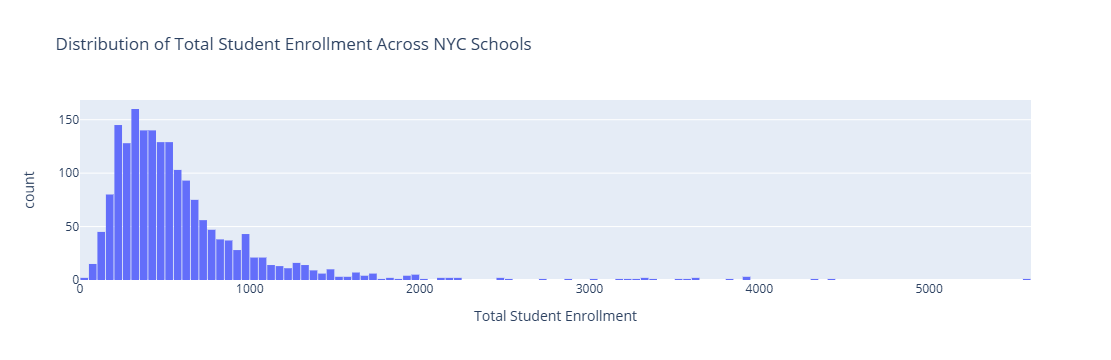

In [94]:
# Plot the distribution of total student enrollment
fig = px.histogram(
    df,
    x='total_enrollment',
    title='Distribution of Total Student Enrollment Across NYC Schools',
    labels={'total_enrollment': 'Total Student Enrollment'}
)
fig.update_layout(bargap=0.1)
fig.show()

**2.** What is the most typical school size in terms of student enrollment?

The most typical school size in terms of enrollment is between 150 and 700 students.

**3.** Are there any outliers? Remember that outliers are values that are "far away" from a tyical value!

There are a few outliers between 0-50, 3800-4000, 4300-4450, and 5550-6000.


**4.** Could outliers (if any) indicate the existence of specialized schools for students with disabilities? Don't be afraid to use ChatGPT to help you in your response!

Yes, the outliers with very small enrollment counts could indicate the existence of specialized schools for students with disabilities. These schools tend to be small on purpose so they can provide more focussed learning environments for each student.



### Task 2b: Students with Disabilities
**1.** Create a histogram to view the distribution of the percentage of students with disabilities across the schools. You'll need to answer the questions that follow.

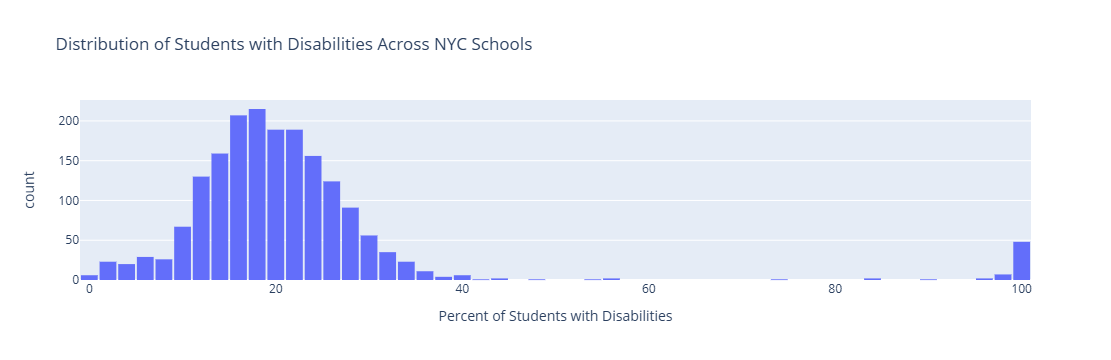

In [95]:
# Plot the distribution of the % of students with disabilities in schools
fig = px.histogram(
    df,
    x='percent_students_with_disabilities',
    title='Distribution of Students with Disabilities Across NYC Schools',
    labels={'percent_students_with_disabilities': 'Percent of Students with Disabilities'}
)
fig.update_layout(bargap=0.1)
fig.show()

**2.** Are most schools clustered around a certain percentage?

Most schools are clustered around the 15-25% range.


**3.** Are there any outliers in your data? What might those outliers mean?

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Try This AI Prompt:</strong> How should I interpret a school with 100% students with disabilities?
  </span>
</div>

There are a number of outliers at or near 100% students with disability. These outliers mark schools that are specifically for the disabled, such as schools for the deaf and/or blind.

#### Task 2c: English Learners
**1.** Create a histogram to view the distribution of the percentage of students who are learning English as a second language in NYC’s public high schools. You'll need to answer the questions that follow.

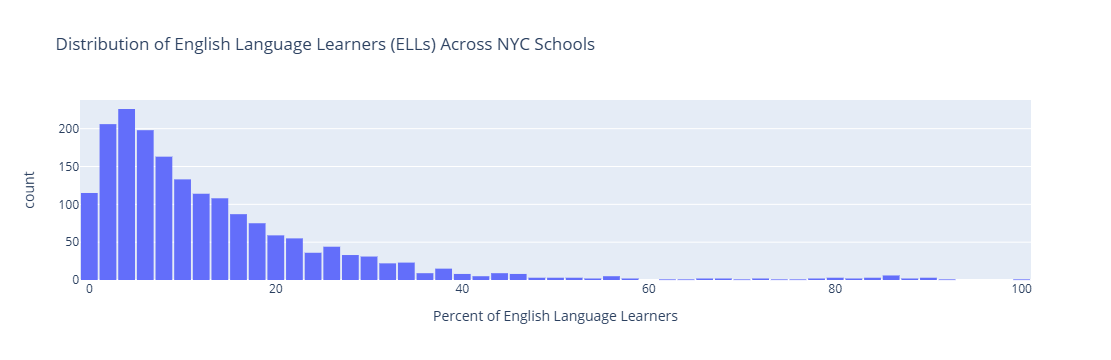

In [96]:
# Plot the distribution of the % of students who are learning English as a second language in schools
fig = px.histogram(
    df,
    x='percent_english_learners',
    title='Distribution of English Language Learners (ELLs) Across NYC Schools',
    labels={'percent_english_learners': 'Percent of English Language Learners'}
)
fig.update_layout(bargap=0.1)
fig.show()

**2.** Are there many schools with high percentages of English learners?

There are very few schools with high percentages of ELLs.


**3.** Are there outliers? What could these outliers indicate about particular schools?

There are a small number of outliers with ELL percentages ranginf from 60-100%. These schools are likely those in areas with dense migrant populations, offer dual language programs, or offer specialized newcomer programs to recent immigrants.



#### Task 2d: Students in Poverty
**1.** Create a histogram to view the distribution of the percentage of students whose families fall below the poverty line in NYC public high schools.

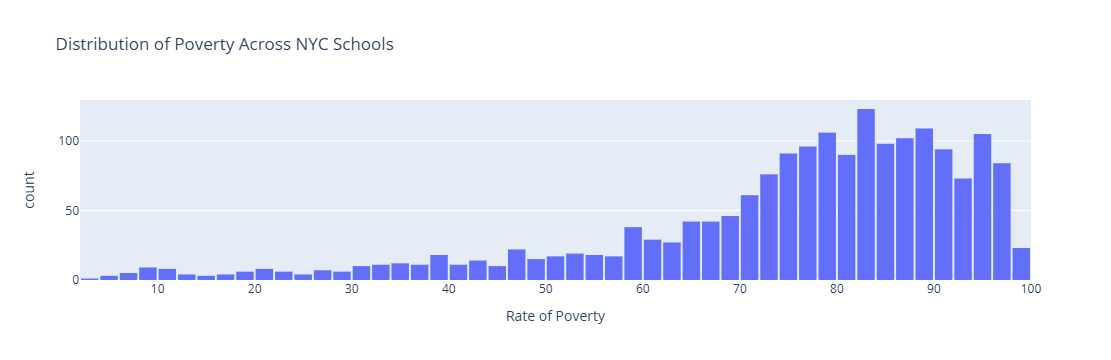

In [97]:
# Plot the distribution of the % of students whose families are below the poverty line in schools
fig = px.histogram(
    df,
    x='percent_poverty',
    title='Distribution of Poverty Across NYC Schools',
    labels={'percent_poverty': 'Rate of Poverty'}
)
fig.update_layout(bargap=0.1)
fig.show()

**2.** Based on these four histograms, what are the typical characteristics of an average NYC public high school in terms of enrollment, student disabilities, English learners, and the percentage of students living below the poverty line?









THe average NYC public high school has a student enrollment of 150-700 students, with 15-25% of those students having some form of disability, and 1-7% of them being ELLs. The average school also suffers from a massive poverty rate.



#### Task 2e: A Relationship Between Poverty and English Language Learners

By plotting these two variables, we aim to see if there is a *correlation* between high poverty rates and a higher proportion of students learning English as a second language. This can help identify trends, such as whether schools in more impoverished areas tend to serve a higher percentage of students who are learning English as a second language.

**1.** Create a scatter plot with the poverty rate on the x-axis and the percentage of English learners on the y-axis.



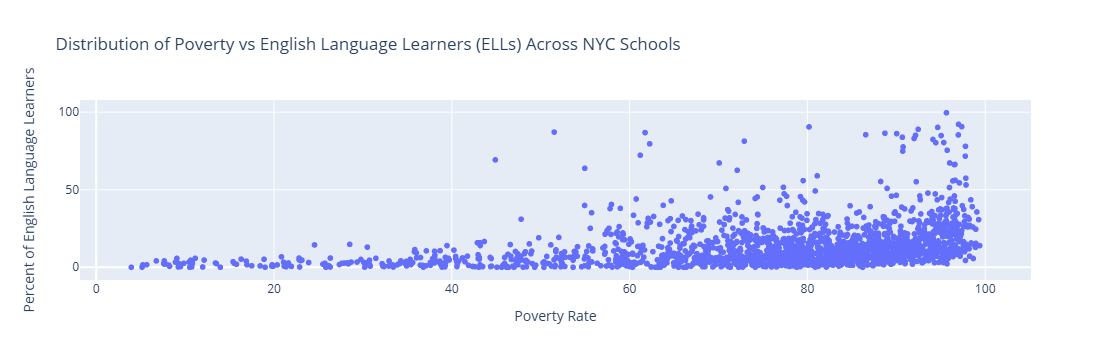

In [98]:
# Create a scatter plot of percent_english_learners vs percent_poverty
fig = px.scatter(
    df,
    x='percent_poverty',
    y='percent_english_learners',
    title='Distribution of Poverty vs English Language Learners (ELLs) Across NYC Schools',
    labels={'percent_poverty': 'Poverty Rate', 'percent_english_learners': 'Percent of English Language Learners'}
)
fig.update_layout(bargap=0.1)
fig.show()

**2.** Is there any visible relationship between the two variables? Do schools with higher poverty rates tend to have more students learning English as a second language?

Schools with higher poverty rates tend to have more ELLs. Schools with higher amounts of ELLs have MUCH higher poverty rates. Though there are still a lot of schools with percentages of ELLs that have massive poverty rates.


**3.** Looking at the scatter plot, what do you think the relationship between poverty and English learners could mean for resource allocation in schools? What implications might this have for educators and policymakers in addressing the needs of these students?

The relationship between poverty and ELLs means that funding is likely not being alocated towards schools in zones with large amounts of new immigrants or historical immigrant poluations. To address the needs of these students, policymakers could provide subsidised lunches, little free libraries, open access to school libraries, or other community outreach programs to help lessen the effects of poverty on disadvantaged students. 



# LevelUp

Congratulations on completing the Milestone! In the last visualization, you created scatter plots to visually inspect whether a relationship might exist between variables.

There is a way to **quantify** the relationship between *any* two variables! It is called **correlation**. Correlation ranges from -1 to 1.

When the correlation between two variables is equal to 1, this means that there is a perfect relationship between them. Two variables that would be (almost!) perfectly correlated are `age` and `birth_year`. If you know someone's year of birth, you can predict their age. If you know their age, you can predict their birth year.

When the correlation between two variables is equal to 0, this means that there is no relationship between two variables. For example, `shoe_size` and `favorite_color`. These two variables are not related in any meaningful way.

A negative correlation means that an increase in one variable leads to a decrease in the other. For example, `sea_level` and `temperature`. As you climb a mountain, increasing your hight above sea level, it gets colder. The temperature decreases.

Pandas offers a quick way to examine the correlation between variables at a single glance: the `.corr()` method applied to a DataFrame. The `.corr()` method will produce a table of correlation coefficients: each row/column intersection is the correlation between the variable named in the row and the variable named in the column.

## Task 3: Correlated Variables

#### Apply the .corr() method to your DataFrame containing the NYC Department of Education data.

Examine the table and determine **which two variables have the strongest correlation, and how strong that correlation is.**

Here's a rough guide to understanding correlation coefficients:
- Correlation between 0 and 0.2 is considered to be non-existent to weak.
- Correlation between 0.2 and 0.4 is considered weak.
- Correlation between 0.4 and 0.6 is considered moderate.
- Correlation between 0.6 and 0.8 is considered to be strong.
- Correlation between 0.8 and 1 is considered to be very strong.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Note: </strong>A variable will always be perfectly correlated with itself! So disregard the diagonal of your output when answering this question!
</span>
</div>

In [99]:
# Apply the .corr() method to the dataframe
df.corr()

,total_enrollment,percent_students_with_disabilities,percent_english_learners,percent_poverty
total_enrollment,1.000000,-0.176817,0.027771,-0.143091
percent_students_with_disabilities,-0.176817,1.000000,0.020820,0.079578
percent_english_learners,0.027771,0.020820,1.000000,0.315477
percent_poverty,-0.143091,0.079578,0.315477,1.000000


The variables with the strogest correlation are percent_poverty and percent_english_learners, with a correlation of 0.315477. Even though this pair has the strongest correlation, it is only a weak correlation.

